## Problem 3: Temperature Shocks and Economic Growth

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

**Read the Stata dataset using Pandas**

In [6]:
data = pd.read_stata("../data/raw/climate_panel.dta")

data.head()

,year,fips60_06,fips,wtem,wpre,wtem50,wpre50,country,country_code,ki,...,gdpWDIGDPAGR,gdpWDIGDPIND,lnrgdpl_t0,_MENA,_SSAF,_LAC,_WEOFF,_EECA,_SEAS,parent
0,1986,AE,AE,25.925922,0.782568,26.917786,14.031917,United Arab Emirates,ARE,23.556521,...,1.940000e+09,5.030000e+10,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE
1,2006,AE,AE,27.815685,1.199482,26.917786,14.031917,United Arab Emirates,ARE,NaN,...,NaN,NaN,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE
2,2003,AE,AE,27.971607,0.598379,26.917786,14.031917,United Arab Emirates,ARE,16.413586,...,8.630000e+09,1.180000e+11,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE
3,1955,AE,AE,26.776577,2.079339,26.917786,14.031917,United Arab Emirates,ARE,NaN,...,NaN,NaN,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE
4,1958,AE,AE,27.213095,1.574364,26.917786,14.031917,United Arab Emirates,ARE,NaN,...,NaN,NaN,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE


In [7]:
data.shape

(9296, 23)

In [8]:
data.head()

,year,fips60_06,fips,wtem,wpre,wtem50,wpre50,country,country_code,ki,...,gdpWDIGDPAGR,gdpWDIGDPIND,lnrgdpl_t0,_MENA,_SSAF,_LAC,_WEOFF,_EECA,_SEAS,parent
0,1986,AE,AE,25.925922,0.782568,26.917786,14.031917,United Arab Emirates,ARE,23.556521,...,1.940000e+09,5.030000e+10,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE
1,2006,AE,AE,27.815685,1.199482,26.917786,14.031917,United Arab Emirates,ARE,NaN,...,NaN,NaN,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE
2,2003,AE,AE,27.971607,0.598379,26.917786,14.031917,United Arab Emirates,ARE,16.413586,...,8.630000e+09,1.180000e+11,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE
3,1955,AE,AE,26.776577,2.079339,26.917786,14.031917,United Arab Emirates,ARE,NaN,...,NaN,NaN,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE
4,1958,AE,AE,27.213095,1.574364,26.917786,14.031917,United Arab Emirates,ARE,NaN,...,NaN,NaN,9.185632,1.0,0.0,0.0,0.0,0.0,0.0,AE


In [9]:
data.columns.tolist()

['year',
 'fips60_06',
 'fips',
 'wtem',
 'wpre',
 'wtem50',
 'wpre50',
 'country',
 'country_code',
 'ki',
 'rgdpl',
 'gdpLCU',
 'gdpSHAREAG',
 'gdpWDIGDPAGR',
 'gdpWDIGDPIND',
 'lnrgdpl_t0',
 '_MENA',
 '_SSAF',
 '_LAC',
 '_WEOFF',
 '_EECA',
 '_SEAS',
 'parent']

**Search for the important columns**

In [15]:
climate = data[
    [
         "fips60_06",
        "fips",
        "country",
        "country_code",
        "year",
        "wtem",
        "wpre",
        "rgdpl",
        "lnrgdpl_t0"
    ]
].copy()

climate.head()

,fips60_06,fips,country,country_code,year,wtem,wpre,rgdpl,lnrgdpl_t0
0,AE,AE,United Arab Emirates,ARE,1986,25.925922,0.782568,20155.898132,9.185632
1,AE,AE,United Arab Emirates,ARE,2006,27.815685,1.199482,NaN,9.185632
2,AE,AE,United Arab Emirates,ARE,2003,27.971607,0.598379,35675.617096,9.185632
3,AE,AE,United Arab Emirates,ARE,1955,26.776577,2.079339,NaN,9.185632
4,AE,AE,United Arab Emirates,ARE,1958,27.213095,1.574364,NaN,9.185632


In [16]:
# Rename columns
climate = climate.rename(columns={
    "fips60_06": "FIPS_60_06",
    "fips": "FIPS",
    "country": "Country",
    "country_code": "Country_Code",
    "year": "Year",
    "wtem": "Temperature",
    "wpre": "Precipitation",
    "rgdpl": "GDP_per_capita",
    "lnrgdpl_t0": "Initial_Log_GDP"
})

climate.head()

,FIPS_60_06,FIPS,Country,Country_Code,Year,Temperature,Precipitation,GDP_per_capita,Initial_Log_GDP
0,AE,AE,United Arab Emirates,ARE,1986,25.925922,0.782568,20155.898132,9.185632
1,AE,AE,United Arab Emirates,ARE,2006,27.815685,1.199482,NaN,9.185632
2,AE,AE,United Arab Emirates,ARE,2003,27.971607,0.598379,35675.617096,9.185632
3,AE,AE,United Arab Emirates,ARE,1955,26.776577,2.079339,NaN,9.185632
4,AE,AE,United Arab Emirates,ARE,1958,27.213095,1.574364,NaN,9.185632


In [17]:
climate[["Country", "Country_Code", "FIPS", "FIPS_60_06"]].head(20)

,Country,Country_Code,FIPS,FIPS_60_06
0,United Arab Emirates,ARE,AE,AE
1,United Arab Emirates,ARE,AE,AE
2,United Arab Emirates,ARE,AE,AE
3,United Arab Emirates,ARE,AE,AE
4,United Arab Emirates,ARE,AE,AE
5,United Arab Emirates,ARE,AE,AE
6,United Arab Emirates,ARE,AE,AE
7,United Arab Emirates,ARE,AE,AE
8,United Arab Emirates,ARE,AE,AE
9,United Arab Emirates,ARE,AE,AE


In [18]:
climate.isna().sum()

FIPS_60_06            0
FIPS                  0
Country               0
Country_Code          0
Year                  0
Temperature           0
Precipitation         0
GDP_per_capita     2702
Initial_Log_GDP     691
dtype: int64

In [19]:
climate[["Country", "Country_Code", "FIPS", "FIPS_60_06"]].nunique()

Country         186
Country_Code    170
FIPS            181
FIPS_60_06      185
dtype: int64

**Create a clean Country Identifier**

In [20]:
climate["Country_ID"] = climate["Country_Code"]

climate["Country_ID"] = climate["Country_ID"].fillna(climate["FIPS"])
climate["Country_ID"] = climate["Country_ID"].fillna(climate["FIPS_60_06"])
climate["Country_ID"] = climate["Country_ID"].fillna(climate["Country"])

climate[["Country", "Country_Code", "FIPS", "FIPS_60_06", "Country_ID"]].head(20)

,Country,Country_Code,FIPS,FIPS_60_06,Country_ID
0,United Arab Emirates,ARE,AE,AE,ARE
1,United Arab Emirates,ARE,AE,AE,ARE
2,United Arab Emirates,ARE,AE,AE,ARE
3,United Arab Emirates,ARE,AE,AE,ARE
4,United Arab Emirates,ARE,AE,AE,ARE
5,United Arab Emirates,ARE,AE,AE,ARE
6,United Arab Emirates,ARE,AE,AE,ARE
7,United Arab Emirates,ARE,AE,AE,ARE
8,United Arab Emirates,ARE,AE,AE,ARE
9,United Arab Emirates,ARE,AE,AE,ARE


In [21]:
climate = climate.dropna(
    subset=[
        "Country_ID",
        "Year",
        "Temperature",
        "Precipitation",
        "GDP_per_capita",
        "Initial_Log_GDP"
    ]
)

climate.shape

(6594, 10)

In [22]:
climate = climate.sort_values(["Country_ID", "Year"])

climate.head()

,FIPS_60_06,FIPS,Country,Country_Code,Year,Temperature,Precipitation,GDP_per_capita,Initial_Log_GDP,Country_ID
65,AF,AF,Afghanistan,AFG,1970,11.716520,2.564826,1731.110272,7.456518,AFG
104,AF,AF,Afghanistan,AFG,1971,11.758612,2.534927,1748.382111,7.456518,AFG
87,AF,AF,Afghanistan,AFG,1972,9.526728,4.500111,2119.625287,7.456518,AFG
82,AF,AF,Afghanistan,AFG,1973,11.098930,3.491065,2119.436183,7.456518,AFG
100,AF,AF,Afghanistan,AFG,1974,10.411225,3.170492,2148.019818,7.456518,AFG


**Create GDP Growth**

In [23]:
climate["Log_GDP_per_capita"] = np.log(climate["GDP_per_capita"])

climate["GDP_Growth"] = climate.groupby("Country_ID")["Log_GDP_per_capita"].diff() * 100

climate[["Country_ID", "Year", "GDP_per_capita", "Log_GDP_per_capita", "GDP_Growth"]].head(10)

,Country_ID,Year,GDP_per_capita,Log_GDP_per_capita,GDP_Growth
65,AFG,1970,1731.110272,7.456518,NaN
104,AFG,1971,1748.382111,7.466446,0.992787
87,AFG,1972,2119.625287,7.658995,19.254847
82,AFG,1973,2119.436183,7.658905,-0.008922
100,AFG,1974,2148.019818,7.672302,1.339630
96,AFG,1975,2263.112348,7.724496,5.219461
94,AFG,1976,2269.601225,7.727359,0.286313
74,AFG,1977,2121.097520,7.659689,-6.767049
78,AFG,1978,2205.369552,7.698650,3.896144
108,AFG,1979,2121.102220,7.659691,-3.895922


**Drop rows where GDP growth could not be calculated**

In [24]:
climate = climate.dropna(
    subset=[
        "GDP_Growth",
        "Temperature",
        "Precipitation",
        "Initial_Log_GDP"
    ]
)

climate.shape

(6426, 12)

**Create Poor Country Dummy**

In [25]:
income_median = climate["Initial_Log_GDP"].median()

climate["Poor_Country"] = np.where(
    climate["Initial_Log_GDP"] < income_median,
    1,
    0
)

climate[["Country_ID", "Initial_Log_GDP", "Poor_Country"]].drop_duplicates().head()

,Country_ID,Initial_Log_GDP,Poor_Country
104,AFG,7.456518,1
193,ALB,8.269252,0
8,ARE,9.185632,0
352,ARG,8.969472,0
252,ARM,7.891484,0


In [26]:
climate.head()

,FIPS_60_06,FIPS,Country,Country_Code,Year,Temperature,Precipitation,GDP_per_capita,Initial_Log_GDP,Country_ID,Log_GDP_per_capita,GDP_Growth,Poor_Country
104,AF,AF,Afghanistan,AFG,1971,11.758612,2.534927,1748.382111,7.456518,AFG,7.466446,0.992787,1
87,AF,AF,Afghanistan,AFG,1972,9.526728,4.500111,2119.625287,7.456518,AFG,7.658995,19.254847,1
82,AF,AF,Afghanistan,AFG,1973,11.098930,3.491065,2119.436183,7.456518,AFG,7.658905,-0.008922,1
100,AF,AF,Afghanistan,AFG,1974,10.411225,3.170492,2148.019818,7.456518,AFG,7.672302,1.339630,1
96,AF,AF,Afghanistan,AFG,1975,10.329297,3.425632,2263.112348,7.456518,AFG,7.724496,5.219461,1


In [27]:
climate[["Country_ID", "Year", "GDP_Growth", "Temperature", "Precipitation", "Poor_Country"]].head()

,Country_ID,Year,GDP_Growth,Temperature,Precipitation,Poor_Country
104,AFG,1971,0.992787,11.758612,2.534927,1
87,AFG,1972,19.254847,9.526728,4.500111,1
82,AFG,1973,-0.008922,11.098930,3.491065,1
100,AFG,1974,1.339630,10.411225,3.170492,1
96,AFG,1975,5.219461,10.329297,3.425632,1


In [28]:
climate["Country_ID"].nunique(), climate["Year"].min(), climate["Year"].max()

(165, np.int16(1951), np.int16(2004))

**Plot: GDP Growth v. Temperature**

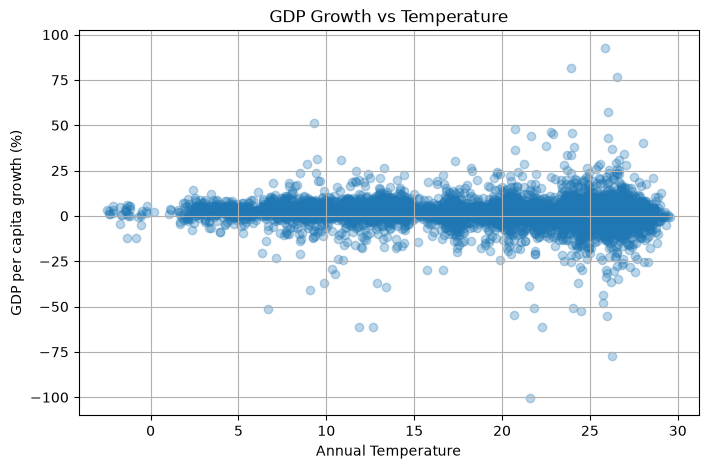

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(climate["Temperature"], climate["GDP_Growth"], alpha=0.3)

plt.xlabel("Annual Temperature")
plt.ylabel("GDP per capita growth (%)")
plt.title("GDP Growth vs Temperature")
plt.grid(True)

plt.show()

**Model 1: Simple Temperature Regression**

In [31]:
y = climate["GDP_Growth"]

X_simple = climate[["Temperature"]]
X_simple = sm.add_constant(X_simple)

simple_model = sm.OLS(y, X_simple).fit()

print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:             GDP_Growth   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     51.87
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           6.62e-13
Time:                        02:28:37   Log-Likelihood:                -21898.
No. Observations:                6426   AIC:                         4.380e+04
Df Residuals:                    6424   BIC:                         4.381e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.4252      0.257     13.328      

**Model 2: Temperature & Precipitation**

In [32]:
X_temp_precip = climate[["Temperature", "Precipitation"]]
X_temp_precip = sm.add_constant(X_temp_precip)

temp_precip_model = sm.OLS(y, X_temp_precip).fit()

print(temp_precip_model.summary())

                            OLS Regression Results                            
Dep. Variable:             GDP_Growth   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     31.38
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           2.76e-14
Time:                        02:29:17   Log-Likelihood:                -21893.
No. Observations:                6426   AIC:                         4.379e+04
Df Residuals:                    6423   BIC:                         4.381e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.2274      0.264     12.236

**Country & Year Fixed Effets**

In [33]:
country_dummies = pd.get_dummies(
    climate["Country_ID"],
    prefix="Country",
    drop_first=True,
    dtype=int
)

year_dummies = pd.get_dummies(
    climate["Year"],
    prefix="Year",
    drop_first=True,
    dtype=int
)

country_dummies.head()

,Country_ALB,Country_ARE,Country_ARG,Country_ARM,Country_AUS,Country_AUT,Country_AZE,Country_BDI,Country_BEL,Country_BEN,...,Country_VEN,Country_VNM,Country_VUT,Country_WSM,Country_YEM,Country_YUG,Country_ZAF,Country_ZAR,Country_ZMB,Country_ZWE
104,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
87,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
82,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Model 3: Country & Year Fxed Effects**

In [34]:
X_fixed = pd.concat(
    [
        climate[["Temperature", "Precipitation"]],
        country_dummies,
        year_dummies
    ],
    axis=1
)

X_fixed = sm.add_constant(X_fixed)

fixed_effects_model = sm.OLS(y, X_fixed).fit()

In [35]:
fixed_effects_results = pd.DataFrame({
    "Variable": ["Temperature", "Precipitation"],
    "Coefficient": [
        fixed_effects_model.params["Temperature"],
        fixed_effects_model.params["Precipitation"]
    ],
    "P-value": [
        fixed_effects_model.pvalues["Temperature"],
        fixed_effects_model.pvalues["Precipitation"]
    ]
})

fixed_effects_results

,Variable,Coefficient,P-value
0,Temperature,-0.156365,0.439415
1,Precipitation,0.001241,0.975353


**Create Interaction Terms**

In [36]:
climate["Temperature_x_Poor"] = climate["Temperature"] * climate["Poor_Country"]

climate["Precipitation_x_Poor"] = climate["Precipitation"] * climate["Poor_Country"]

climate[
    [
        "Temperature",
        "Poor_Country",
        "Temperature_x_Poor",
        "Precipitation",
        "Precipitation_x_Poor"
    ]
].head()

,Temperature,Poor_Country,Temperature_x_Poor,Precipitation,Precipitation_x_Poor
104,11.758612,1,11.758612,2.534927,2.534927
87,9.526728,1,9.526728,4.500111,4.500111
82,11.098930,1,11.098930,3.491065,3.491065
100,10.411225,1,10.411225,3.170492,3.170492
96,10.329297,1,10.329297,3.425632,3.425632


**Model 4: Fixed effects + Poor-country Interaction**

In [37]:
X_interaction = pd.concat(
    [
        climate[
            [
                "Temperature",
                "Precipitation",
                "Temperature_x_Poor",
                "Precipitation_x_Poor"
            ]
        ],
        country_dummies,
        year_dummies
    ],
    axis=1
)

X_interaction = sm.add_constant(X_interaction)

interaction_model = sm.OLS(y, X_interaction).fit()

In [38]:
interaction_results = pd.DataFrame({
    "Variable": [
        "Temperature",
        "Precipitation",
        "Temperature x Poor",
        "Precipitation x Poor"
    ],
    "Coefficient": [
        interaction_model.params["Temperature"],
        interaction_model.params["Precipitation"],
        interaction_model.params["Temperature_x_Poor"],
        interaction_model.params["Precipitation_x_Poor"]
    ],
    "P-value": [
        interaction_model.pvalues["Temperature"],
        interaction_model.pvalues["Precipitation"],
        interaction_model.pvalues["Temperature_x_Poor"],
        interaction_model.pvalues["Precipitation_x_Poor"]
    ]
})

interaction_results

,Variable,Coefficient,P-value
0,Temperature,0.242850,0.298875
1,Precipitation,-0.020705,0.711318
2,Temperature x Poor,-1.209545,0.000782
3,Precipitation x Poor,0.033961,0.669272


**Compare All Models**

In [39]:
comparison = pd.DataFrame({
    "Model": [
        "Simple: Temperature only",
        "Temperature + Precipitation",
        "Country + Year Fixed Effects",
        "Fixed Effects + Poor Interactions"
    ],
    "Temperature Coefficient": [
        simple_model.params["Temperature"],
        temp_precip_model.params["Temperature"],
        fixed_effects_model.params["Temperature"],
        interaction_model.params["Temperature"]
    ],
    "Temperature x Poor Coefficient": [
        np.nan,
        np.nan,
        np.nan,
        interaction_model.params["Temperature_x_Poor"]
    ],
    "R-squared": [
        simple_model.rsquared,
        temp_precip_model.rsquared,
        fixed_effects_model.rsquared,
        interaction_model.rsquared
    ],
    "Adjusted R-squared": [
        simple_model.rsquared_adj,
        temp_precip_model.rsquared_adj,
        fixed_effects_model.rsquared_adj,
        interaction_model.rsquared_adj
    ]
})

comparison

,Model,Temperature Coefficient,Temperature x Poor Coefficient,R-squared,Adjusted R-squared
0,Simple: Temperature only,-0.090899,NaN,0.008009,0.007855
1,Temperature + Precipitation,-0.107357,NaN,0.009675,0.009367
2,Country + Year Fixed Effects,-0.156365,NaN,0.089838,0.057720
3,Fixed Effects + Poor Interactions,0.242850,-1.209545,0.091611,0.059252


**Calculate Temperature Effect for Richer vs Poor countries**

In [40]:
rich_country_temp_effect = interaction_model.params["Temperature"]

poor_country_temp_effect = (
    interaction_model.params["Temperature"] 
    + interaction_model.params["Temperature_x_Poor"]
)

effects = pd.DataFrame({
    "Group": ["Richer countries", "Poor countries"],
    "Estimated temperature effect on GDP growth": [
        rich_country_temp_effect,
        poor_country_temp_effect
    ]
})

effects

,Group,Estimated temperature effect on GDP growth
0,Richer countries,0.242850
1,Poor countries,-0.966694


**p-Value for the Poor Country Effect**

In [41]:
poor_temp_test = interaction_model.t_test("Temperature + Temperature_x_Poor = 0")

print(poor_temp_test)

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.9667      0.316     -3.062      0.002      -1.586      -0.348


### Interpretation of Results

This exercise estimates the relationship between annual temperature and GDP per capita growth using country-year panel data. The analysis is inspired by Dell, Jones and Olken’s study of temperature shocks and economic growth.

The simple temperature-only model has very low explanatory power, with an R-squared of 0.008. This suggests that temperature alone explains only a small portion of the variation in annual GDP growth across countries and years. Adding precipitation increases the R-squared slightly to 0.0097.

The model improves after including country and year fixed effects. The R-squared rises to 0.0898, indicating that controlling for permanent country-level differences and common global year shocks helps explain more of the variation in GDP growth.

The main specification adds interaction terms between climate variables and the poor-country dummy. In this model, the coefficient on Temperature is 0.2429, but it is not statistically significant. This means there is no strong evidence that annual temperature has a clear effect on GDP growth for richer countries in this specification.

The coefficient on Temperature × Poor is -1.2095 and statistically significant, with a p-value of 0.0008. This suggests that the temperature-growth relationship is significantly more negative for poor countries. Combining the Temperature coefficient with the Temperature × Poor coefficient gives an estimated temperature effect of approximately -0.9667 for poor countries. Therefore, a 1°C increase in annual temperature is associated with about a 0.97 percentage point reduction in GDP per capita growth for poor countries.

Overall, the results support the broad conclusion that poorer countries are more economically vulnerable to temperature shocks than richer countries.

### Combined Temperature Effect for Poor Countries

To test whether the total temperature effect for poor countries is statistically significant, I tested the joint expression: Temperature + Temperature × Poor = 0. The estimated combined effect is -0.9667, with a p-value of 0.002. This means that for poor countries, a 1°C increase in annual temperature is associated with approximately a 0.97 percentage point reduction in GDP per capita growth.

The 95% confidence interval ranges from -1.586 to -0.348. Since the entire interval is below zero, the result provides evidence that temperature shocks have a statistically significant negative effect on economic growth in poor countries. This finding is consistent with the broad conclusion of Dell, Jones and Olken that poor countries are more vulnerable to higher temperatures.

### Conclusion

This replication-style exercise finds that the relationship between temperature and GDP growth differs across richer and poorer countries. The temperature coefficient for richer countries is positive but statistically insignificant, meaning there is no strong evidence of a temperature-growth effect for richer countries in this specification.

However, the interaction between temperature and the poor-country dummy is negative and statistically significant. The combined estimated temperature effect for poor countries is -0.9667, suggesting that a 1°C increase in annual temperature is associated with nearly a 1 percentage point reduction in GDP per capita growth. Therefore, the results support the idea that poorer countries are more economically vulnerable to temperature shocks.

## END